In [1]:
from models.hierarchical_grating_model import HierarchicalGratingModel
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")

In [3]:
exc_images = np.load(exc_fname)

In [4]:
exc_images_flat = exc_images.reshape(exc_images.shape[0], -1)

In [5]:
csim = cosine_similarity(exc_images_flat)

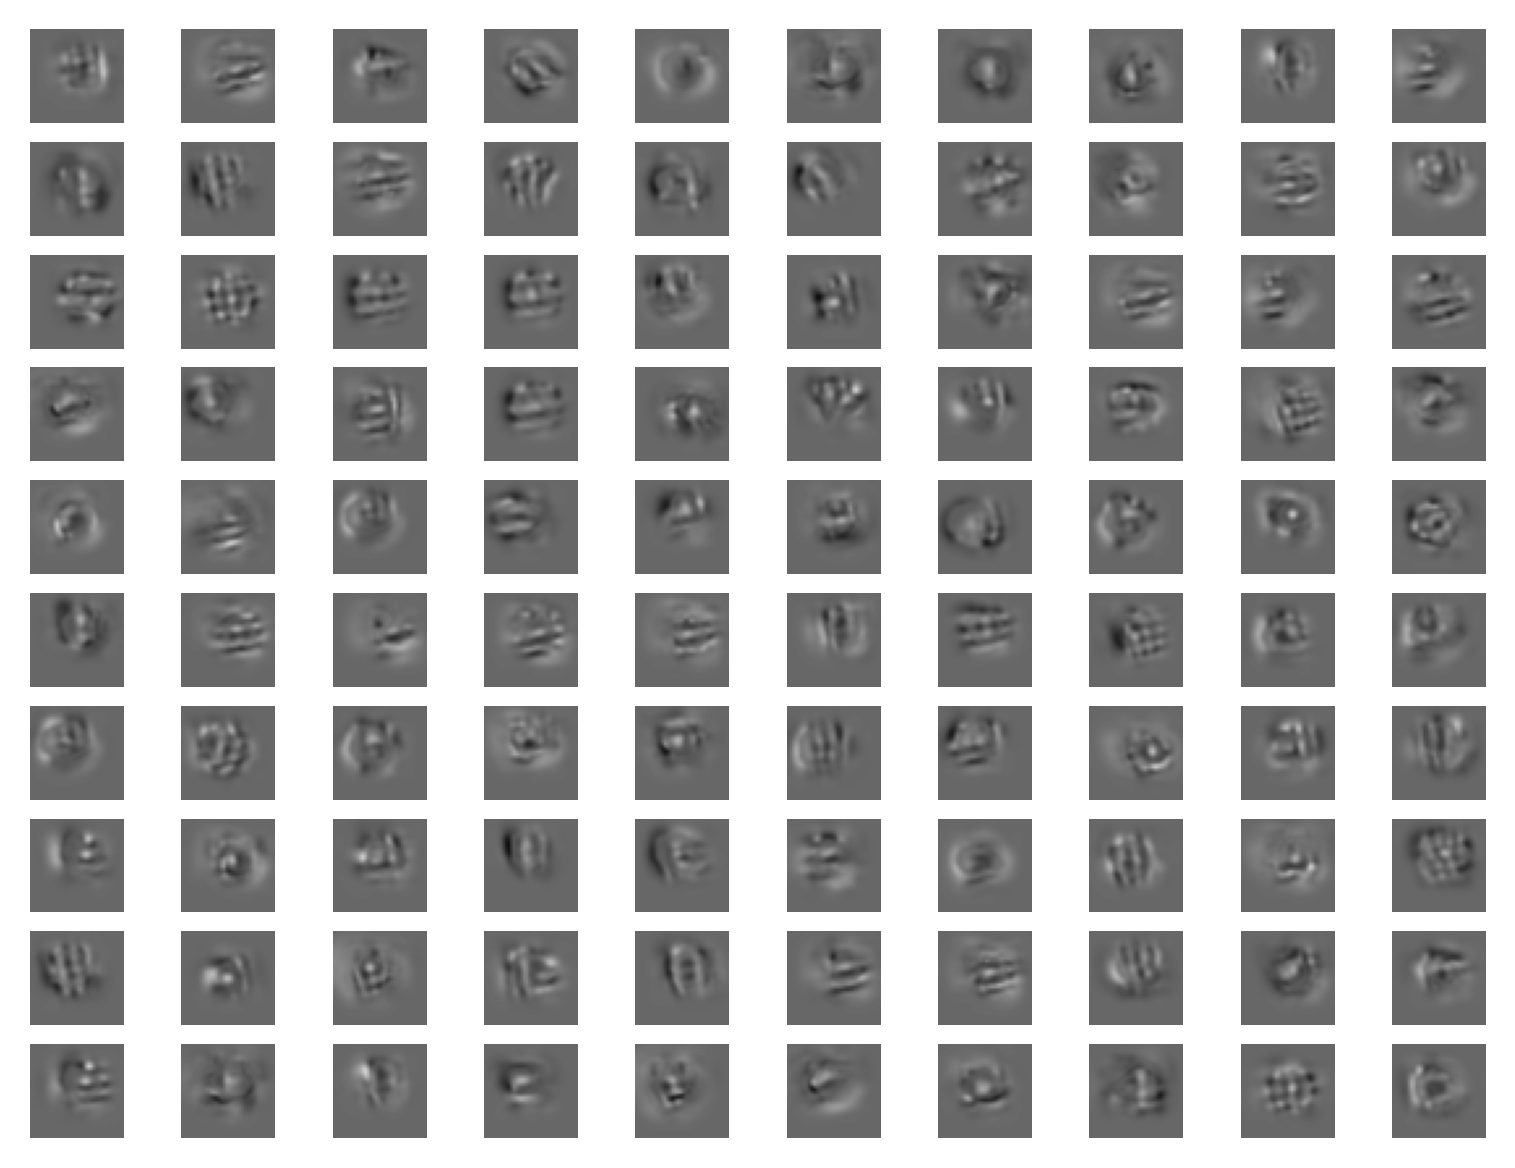

In [6]:
fig, axs = plt.subplots(10, 10, dpi=300)
vmin = np.min(exc_images)
vmax = np.max(exc_images)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(exc_images[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [7]:
csim.shape

(960, 960)

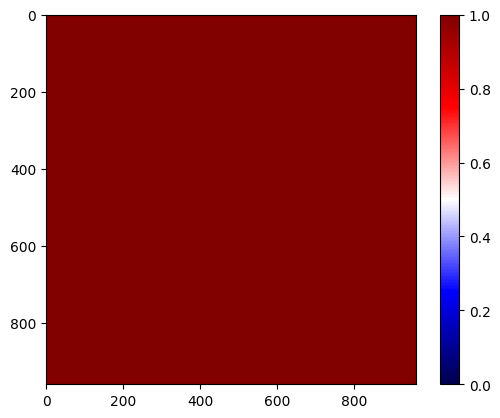

In [8]:
fig, ax = plt.subplots()
im = ax.imshow(csim, cmap="seismic", vmin=0, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)

In [9]:
raw_exc_stimuli = np.load(
    "/src/project/data/experiment/exc_images.npy", allow_pickle=True
)

In [10]:
raw_exc_stimuli = np.array([x for x in raw_exc_stimuli])

In [11]:
raw_exc_stimuli_flat = raw_exc_stimuli.reshape(raw_exc_stimuli.shape[0], -1)

In [12]:
raw_exc_stimuli_flat[0].min(), raw_exc_stimuli_flat[0].max()

(77, 176)

In [13]:
csim_raw = cosine_similarity(raw_exc_stimuli_flat)

Text(0.5, 1.0, 'Cosine sim between exc stimuli')

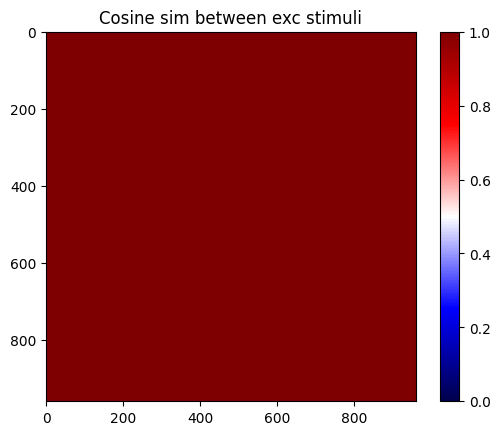

In [14]:
fig, ax = plt.subplots()
im = ax.imshow(csim_raw, cmap="seismic", vmin=0, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)
ax.set_title("Cosine sim between exc stimuli")

Text(0.5, 1.0, 'Histogram of cosine sim between exc stimuli')

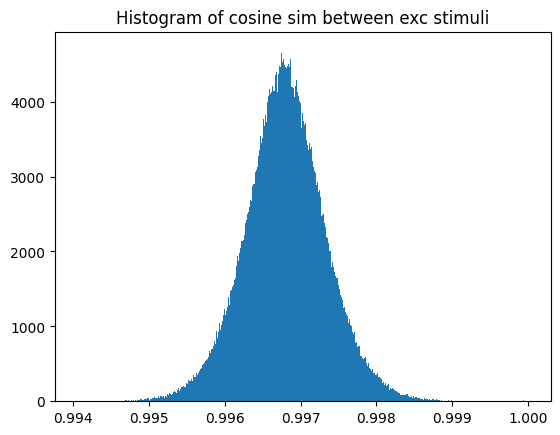

In [15]:
plt.hist(csim_raw.flatten(), bins=1000)
plt.title("Histogram of cosine sim between exc stimuli")

(array([6.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 6.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        4.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00,
        4.000e+00, 0.000e+00, 4.000e+00, 4.000e+00, 4.000e+00, 8.000e+00,
        4.000e+00, 6.000e+00, 2.000e+00, 2.000e+00, 4.000e+00, 2.000e+00,
        6.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 4.000e+00, 8.000e+00,
        6.000e+00, 2.000e+00, 0.000e+0

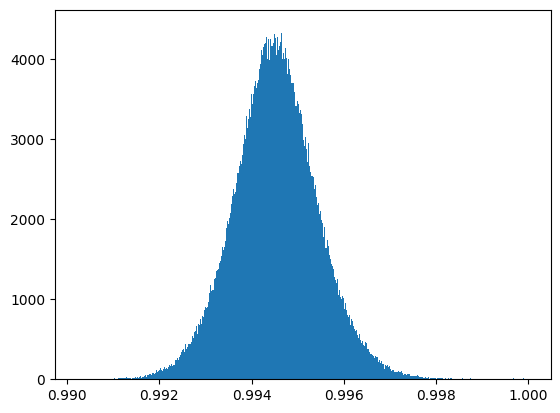

In [16]:
plt.hist(csim.flatten(), bins=1000)

In [17]:
raw_exc_stimuli_flat.shape

(960, 36864)

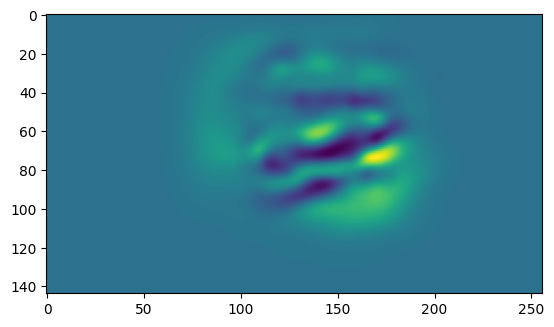

In [22]:
plt.imshow(raw_exc_stimuli[1])

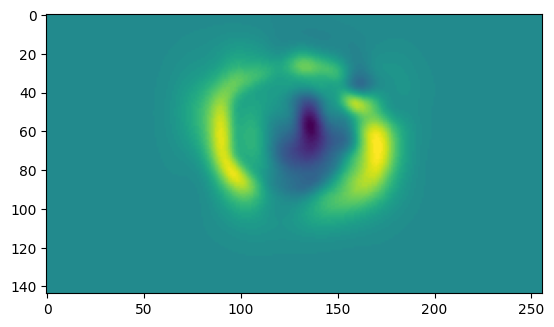

In [19]:
plt.imshow(raw_exc_stimuli[4])

In [23]:
cosine_similarity(
    raw_exc_stimuli_flat[1].reshape(1, -1), raw_exc_stimuli_flat[4].reshape(1, -1)
)

array([[0.99794071]])

In [24]:
raw_exc_stimuli_flat[1].shape

(36864,)

In [25]:
raw_exc_stimuli_flat[4].shape

(36864,)

In [26]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [40]:
cosine_sim(raw_exc_stimuli_flat[1], raw_exc_stimuli_flat[4])

4.367399799738311e-07

In [50]:
cosine_similarity(
    raw_exc_stimuli_flat[1].reshape(1, -1), raw_exc_stimuli_flat[4].reshape(1, -1)
)

array([[0.99794071]])

In [48]:
raw_exc_stimuli_flat[1]

array([114, 114, 114, ..., 114, 114, 114], dtype=uint8)

In [47]:
raw_exc_stimuli_flat[4]

array([114, 114, 114, ..., 114, 114, 114], dtype=uint8)

In [63]:
def custom_cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)

    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity


# Example vectors
vector_a = raw_exc_stimuli_flat[1]
vector_b = raw_exc_stimuli_flat[4]

# Calculate cosine similarity using custom implementation
custom_similarity = custom_cosine_similarity(vector_a, vector_b)

# Calculate cosine similarity using scikit-learn
sklearn_similarity = cosine_similarity(
    vector_a.reshape(1, -1), vector_b.reshape(1, -1)
)[0, 0]

# Compare the results
print("Custom Cosine Similarity:", custom_similarity)
print("Scikit-learn Cosine Similarity:", sklearn_similarity)

# Check if the results are approximately equal
if np.isclose(custom_similarity, sklearn_similarity):
    print("The cosine similarities are the same.")
else:
    print("The cosine similarities are different.")

Custom Cosine Similarity: 4.367399799738311e-07
Scikit-learn Cosine Similarity: 0.9979407126145866
The cosine similarities are different.


In [54]:
raw_exc_stimuli_flat.shape

(960, 36864)